In [1]:
!pip install timm torch-ema

from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import timm
import h5py
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torch_ema import ExponentialMovingAverage
from sklearn.model_selection import train_test_split
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using: cuda


In [2]:
train_path = "/content/drive/MyDrive/morph_project/processed/train.h5"
test_path  = "/content/drive/MyDrive/morph_project/processed/test.h5"

with h5py.File(train_path, "r") as f:
    X = np.array(f["X"])
    y = np.array(f["y"])

with h5py.File(test_path, "r") as f:
    X_test = np.array(f["X"])
    y_test = np.array(f["y"])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (5741, 224, 224, 3)
Val: (1436, 224, 224, 3)
Test: (1803, 224, 224, 3)


In [3]:
img_size = 224

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(img_size, scale=(0.65, 1.0)),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ColorJitter(0.3, 0.3, 0.2, 0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


In [4]:
class H5Dataset(Dataset):
    def __init__(self, X, y, transform):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        img = self.transform(img)
        return img, torch.tensor(self.y[idx]).long()

# Compute sample weights for oversampling
class_counts = np.bincount(y_train)
weights = 1. / class_counts
sample_weights = weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    H5Dataset(X_train, y_train, train_transform),
    batch_size=32,
    sampler=sampler,
    num_workers=2
)

val_loader = DataLoader(
    H5Dataset(X_val, y_val, val_transform),
    batch_size=32,
    shuffle=False,
    num_workers=2
)


In [5]:
def mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    mixed = lam * x + (1 - lam) * x[idx]
    return mixed, y, y[idx], lam


In [6]:
class ConvNeXtClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            "convnextv2_tiny.fcmae_ft_in1k",
            pretrained=True,
            num_classes=0
        )
        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

model = ConvNeXtClassifier().to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

In [7]:
class_weights = torch.tensor([1.0, 4.5]).to(device)  # illicit weighted more
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=35, eta_min=1e-6
)

ema = ExponentialMovingAverage(model.parameters(), decay=0.999)


In [8]:
epochs = 35
best_val_acc = 0
save_path = "/content/drive/MyDrive/morph_project/models/convnextv2_best_224_finetuned.pth"

for epoch in range(epochs):

    model.train()
    tr_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        imgs, y_a, y_b, lam = mixup(imgs, labels)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
        loss.backward()
        optimizer.step()
        ema.update()

        tr_loss += loss.item()

    # Validation with EMA weights
    model.eval()
    v_loss, v_acc = 0, 0

    with ema.average_parameters():
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                v_loss += criterion(outputs, labels).item()
                v_acc  += (torch.argmax(outputs, 1) == labels).float().mean().item()

    v_loss /= len(val_loader)
    v_acc  /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f}")

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), save_path)
        print("🔥 BEST Model Saved!")

    scheduler.step()

print("Training Done!")
print("Best Val Accuracy:", best_val_acc)


Epoch 1/35 | Val Loss: 0.9489 | Val Acc: 0.1710
🔥 BEST Model Saved!
Epoch 2/35 | Val Loss: 0.9461 | Val Acc: 0.1856
🔥 BEST Model Saved!
Epoch 3/35 | Val Loss: 0.8752 | Val Acc: 0.2108
🔥 BEST Model Saved!
Epoch 4/35 | Val Loss: 0.8539 | Val Acc: 0.2555
🔥 BEST Model Saved!
Epoch 5/35 | Val Loss: 0.8505 | Val Acc: 0.3059
🔥 BEST Model Saved!
Epoch 6/35 | Val Loss: 0.8370 | Val Acc: 0.3322
🔥 BEST Model Saved!
Epoch 7/35 | Val Loss: 0.8242 | Val Acc: 0.3650
🔥 BEST Model Saved!
Epoch 8/35 | Val Loss: 0.7996 | Val Acc: 0.4116
🔥 BEST Model Saved!
Epoch 9/35 | Val Loss: 0.7855 | Val Acc: 0.4689
🔥 BEST Model Saved!
Epoch 10/35 | Val Loss: 0.7389 | Val Acc: 0.5281
🔥 BEST Model Saved!
Epoch 11/35 | Val Loss: 0.7134 | Val Acc: 0.5665
🔥 BEST Model Saved!
Epoch 12/35 | Val Loss: 0.7052 | Val Acc: 0.5956
🔥 BEST Model Saved!
Epoch 13/35 | Val Loss: 0.7100 | Val Acc: 0.6088
🔥 BEST Model Saved!
Epoch 14/35 | Val Loss: 0.7112 | Val Acc: 0.6268
🔥 BEST Model Saved!
Epoch 15/35 | Val Loss: 0.7131 | Val Acc: 0

In [1]:
import torch
import torch.nn as nn
import timm
import numpy as np
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import h5py

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ======================================================
# Load Test Dataset
# ======================================================

test_path = "/content/drive/MyDrive/morph_project/processed/test.h5"

with h5py.File(test_path, "r") as f:
    X_test = np.array(f["X"])
    y_test = np.array(f["y"])

print("Test loaded:", X_test.shape, y_test.shape)

img_size = 224

infer_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

class TestDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]

        # --- FIX any dimension issues ---
        img = np.squeeze(img)

        # Convert float → uint8
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8)

        # Grayscale → RGB
        if img.ndim == 2:
            img = np.stack([img]*3, axis=-1)

        # CHW → HWC
        if img.ndim == 3 and img.shape[0] == 3:
            img = np.transpose(img, (1, 2, 0))

        img = Image.fromarray(img)
        img = infer_transform(img)

        return img, torch.tensor(self.y[idx]).long()


test_loader = DataLoader(TestDataset(X_test, y_test),
                         batch_size=32, shuffle=False)

# ======================================================
# Load Model
# ======================================================

class ConvNeXtClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            "convnextv2_tiny.fcmae_ft_in1k",
            pretrained=False,
            num_classes=0
        )
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

model_path = "/content/drive/MyDrive/morph_project/models/convnextv2_best_224_finetuned.pth"

model = ConvNeXtClassifier().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("\nModel Loaded Successfully!")

# ======================================================
# Run Predictions
# ======================================================

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# ======================================================
# Generate Precision, Recall, F1-score
# ======================================================

print("\n======================")
print("  CLASSIFICATION REPORT")
print("======================")
print(classification_report(all_labels, all_preds,
                            target_names=["Licit", "Illicit"]))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Using: cuda
Test loaded: (1803, 224, 224, 3) (1803,)

Model Loaded Successfully!

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Licit       0.91      0.80      0.85      1489
     Illicit       0.40      0.63      0.49       314

    accuracy                           0.77      1803
   macro avg       0.66      0.72      0.67      1803
weighted avg       0.82      0.77      0.79      1803


Confusion Matrix:
[[1197  292]
 [ 116  198]]


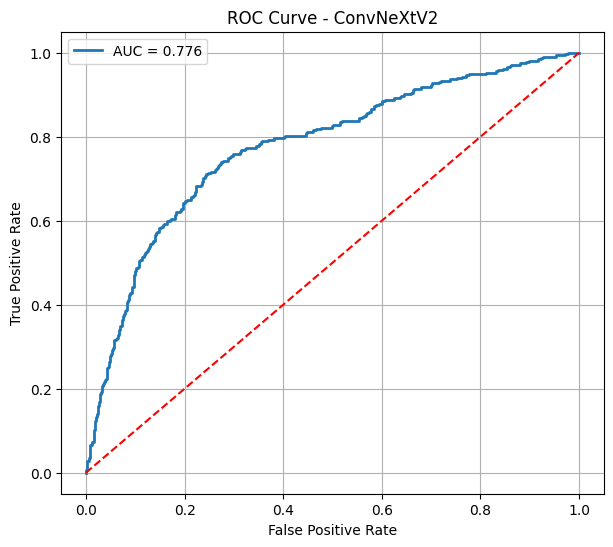

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

# Get probabilities for ROC
probs = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        soft = F.softmax(outputs, dim=1)[:, 1]   # probability of Illicit class
        probs.extend(soft.cpu().numpy())

# Compute ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, probs)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ConvNeXtV2")
plt.legend()
plt.grid(True)
plt.show()


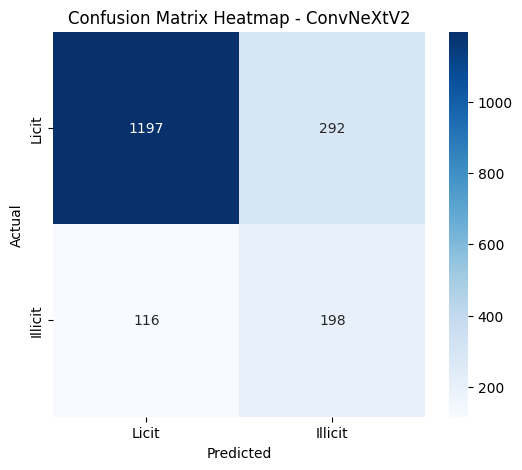

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Licit", "Illicit"],
            yticklabels=["Licit", "Illicit"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap - ConvNeXtV2")
plt.show()


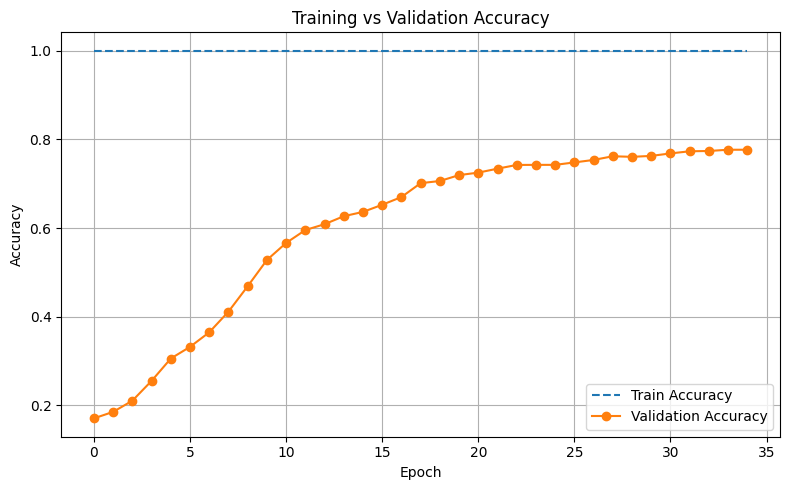

In [6]:
val_accs = [
    0.1710, 0.1856, 0.2108, 0.2555, 0.3059, 0.3322, 0.3650, 0.4116,
    0.4689, 0.5281, 0.5665, 0.5956, 0.6088, 0.6268, 0.6365, 0.6526,
    0.6700, 0.7013, 0.7062, 0.7195, 0.7251, 0.7340, 0.7424, 0.7426,
    0.7426, 0.7481, 0.7537, 0.7620, 0.7607, 0.7628, 0.7684, 0.7732,
    0.7739, 0.7767, 0.7767
]

# OPTION A (Recommended)
train_accs = [1.0] * 35

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_accs, label='Train Accuracy', linestyle='--')
plt.plot(val_accs,  label='Validation Accuracy', marker='o')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
from google.colab import files
from PIL import Image
import torch
import torch.nn as nn
import timm
from torchvision import transforms

# ===============================
# Load Best Model
# ===============================

class ConvNeXtClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            "convnextv2_tiny.fcmae_ft_in1k",
            pretrained=False,
            num_classes=0
        )
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

model_path = "/content/drive/MyDrive/morph_project/models/convnextv2_best_224_finetuned.pth"

best_model = ConvNeXtClassifier().to(device)
best_model.load_state_dict(torch.load(model_path, map_location=device))
best_model.eval()

print("🔥 Best ConvNeXtV2 model loaded successfully!")


# ===============================
# Inference Transform
# ===============================

img_size = 224

infer_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# ===============================
# Prediction Function
# ===============================

def predict_user_image(model, img_path):
    img = Image.open(img_path).convert("RGB")

    img_tensor = infer_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    classes = ["Licit", "Illicit"]

    print("\nImage:", img_path)
    print("Prediction:", classes[pred])
    print("Confidence:", round(float(probs[0][pred]), 4))


# ===============================
# Upload & Predict
# ===============================

uploaded = files.upload()

for filename in uploaded.keys():
    predict_user_image(best_model, filename)


🔥 Best ConvNeXtV2 model loaded successfully!


Saving casias2.png to casias2.png

Image: casias2.png
Prediction: Licit
Confidence: 0.7224
